# 潜在扩散模型与 Stable Diffusion 架构

> **难度：** 中级 | **时间：** 约 45 分钟

像素空间的扩散模型虽然可行，但在处理高分辨率图像时**慢得令人痛苦**。一张 512x512x3 的图像有 786,432 个维度——在所有这些数值上运行数百步去噪的神经网络，计算开销是巨大的。

「潜在扩散模型」（Latent Diffusion Model, LDM）通过先将图像压缩到一个很小的「潜在空间」（Latent Space），然后在那里完成所有创作工作来解决这一问题。可以这样理解：

> *把一张照片压缩成一张小草稿，在草稿上完成所有绘画，再放大回全分辨率。*

本笔记本涵盖以下内容：
1. 为什么潜在空间可以节省计算量和内存
2. VAE 压缩引擎
3. 带有跳跃连接的 UNet 架构
4. 通过交叉注意力实现文本条件引导
5. 完整的 Stable Diffusion 端到端流水线
6. 生产环境中的工程考量

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.diffusion import (
    linear_beta_schedule, compute_alpha_bars, q_sample,
)
from mp_tutorial.formatting import info_box
from mp_tutorial.plantuml import render_plantuml
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

import math
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


---
## 1. 为什么使用潜在空间？

「潜在扩散」的核心洞见很简单：**高分辨率图像包含大量冗余信息**。大多数相邻像素都是相似的。一个好的编码器可以将 512x512 的图像压缩为更小的表示，而几乎不损失信息。

在压缩后的**潜在空间**中运行扩散过程，我们可以获得：
- **更快的训练** —— 每步需要处理的数值更少
- **更低的内存** —— UNet 中的张量更小
- **相同的视觉质量** —— 解码器可以重建精细细节

让我们量化一下这些节省。

In [2]:
# Pixel space vs Latent space: the numbers
pixel_h, pixel_w, pixel_c = 512, 512, 3
latent_h, latent_w, latent_c = 64, 64, 4  # 8x spatial compression, 4 latent channels

pixel_elements = pixel_h * pixel_w * pixel_c
latent_elements = latent_h * latent_w * latent_c
compression_ratio = pixel_elements / latent_elements

print("=== Pixel Space vs Latent Space ===")
print(f"Pixel:  {pixel_h}x{pixel_w}x{pixel_c} = {pixel_elements:>10,} dimensions")
print(f"Latent: {latent_h}x{latent_w}x{latent_c} = {latent_elements:>10,} dimensions")
print(f"Compression ratio: {compression_ratio:.0f}x fewer values!")
print()
print("Memory comparison (FP16):")
print(f"  Pixel:  {pixel_elements * 2 / 1024:.0f} KB per image")
print(f"  Latent: {latent_elements * 2 / 1024:.0f} KB per image")
print()
print("Self-attention cost (S^2 where S = spatial tokens):")
print(f"  Pixel:  ({pixel_h}x{pixel_w})^2 = {(pixel_h*pixel_w)**2 / 1e9:.1f} billion elements")
print(f"  Latent: ({latent_h}x{latent_w})^2 = {(latent_h*latent_w)**2 / 1e6:.1f} million elements")
print(f"  Attention speedup: ~{(pixel_h*pixel_w)**2 / (latent_h*latent_w)**2:.0f}x")

=== Pixel Space vs Latent Space ===
Pixel:  512x512x3 =    786,432 dimensions
Latent: 64x64x4 =     16,384 dimensions
Compression ratio: 48x fewer values!

Memory comparison (FP16):
  Pixel:  1536 KB per image
  Latent: 32 KB per image

Self-attention cost (S^2 where S = spatial tokens):
  Pixel:  (512x512)^2 = 68.7 billion elements
  Latent: (64x64)^2 = 16.8 million elements
  Attention speedup: ~4096x


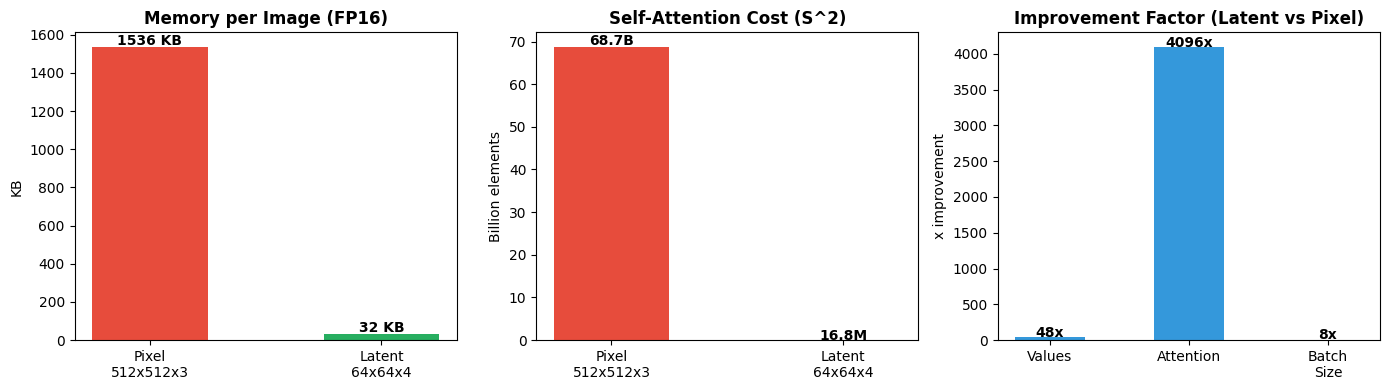

In [3]:
# Visualize the compression savings
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

categories = ['Pixel\n512x512x3', 'Latent\n64x64x4']
colors = ['#E74C3C', '#27AE60']

# Memory comparison
memory_vals = [pixel_elements * 2 / 1024, latent_elements * 2 / 1024]
axes[0].bar(categories, memory_vals, color=colors, width=0.5)
axes[0].set_title('Memory per Image (FP16)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('KB')
for i, v in enumerate(memory_vals):
    axes[0].text(i, v + 10, f'{v:.0f} KB', ha='center', fontweight='bold')

# Attention cost comparison
attn_pixel = (pixel_h * pixel_w) ** 2 / 1e9
attn_latent = (latent_h * latent_w) ** 2 / 1e9
axes[1].bar(categories, [attn_pixel, attn_latent], color=colors, width=0.5)
axes[1].set_title('Self-Attention Cost (S^2)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Billion elements')
axes[1].text(0, attn_pixel + 0.5, f'{attn_pixel:.1f}B', ha='center', fontweight='bold')
axes[1].text(1, attn_latent + 0.005, f'{attn_latent*1000:.1f}M', ha='center', fontweight='bold')

# Speedup factors
speedups = [compression_ratio, attn_pixel / attn_latent, 8]
labels = ['Values', 'Attention', 'Batch\nSize']
axes[2].bar(labels, speedups, color=['#3498DB'] * 3, width=0.5)
axes[2].set_title('Improvement Factor (Latent vs Pixel)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('x improvement')
for i, v in enumerate(speedups):
    axes[2].text(i, v + 1, f'{v:.0f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

info_box(
    "<b>「潜在扩散」</b>在压缩空间中运行扩散过程，将计算量减少约 "
    "<b>48 倍</b>，同时保持图像质量。一张 512x512 图像（786,432 维）被压缩为 "
    "64x64x4 的潜在表示（16,384 维）。这使得在消费级 GPU 上生成高分辨率图像成为可能。",
    title="核心洞见"
)

---
## 2. VAE：压缩引擎

变分自编码器（VAE）是像素空间与潜在空间之间的桥梁。它有两个部分：

- **编码器**（Encoder）：接收全分辨率图像，将其压缩为一个小的潜在表示
- **解码器**（Decoder）：接收潜在表示，重建出全分辨率图像

VAE 是单独训练的（在扩散模型之前），然后在扩散训练期间被**冻结**。可以把它想象成一个固定的压缩编解码器——就像 JPEG，但是是学习到的，而且好得多。

In [4]:
# VAE architecture diagram
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 13
skinparam rectangleBorderColor #555

rectangle "VAE Encoder" as enc #LightBlue {
  rectangle "Conv layers" as conv1
  rectangle "Downsample 8x" as down
  rectangle "\u03bc, \u03c3" as musig
}

rectangle "Latent Space\n(64x64x4)" as latent #LightGreen

rectangle "VAE Decoder" as dec #LightCoral {
  rectangle "Upsample 8x" as up
  rectangle "Conv layers" as conv2
}

conv1 --> down --> musig --> latent --> up --> conv2

note top of enc
  512x512x3 image in
end note

note top of dec
  512x512x3 image out
end note
@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 13
skinparam rectangleBorderColor #555

rectangle "VAE Encoder" as enc #LightBlue {
  rectangle "Conv layers" as conv1
  rectangle "Downsample 8x" as down
  rectangle "μ, σ" as musig
}

rectangle "Latent Space
(64x64x4)" as latent #LightGreen

rectangle "VAE Decoder" as dec #LightCoral {
  rectangle "Upsample 8x" as up
  rectangle "Conv layers" as conv2
}

conv1 --> down --> musig --> latent --> up --> conv2

note top of enc
  512x512x3 image in
end note

note top of dec
  512x512x3 image out
end note
@enduml
```

In [5]:
info_box(
    """<b>什么是 VAE（变分自编码器）？</b><br><br>
    VAE 是一种神经网络，它学习将数据压缩为一个小的「潜在」向量，
    然后重建它。相比普通自编码器，关键创新在于潜在空间被<b>正则化</b>
    为服从高斯分布（通过 KL 散度损失）。<br><br>
    这意味着：<br>
    <ul>
    <li>潜在空间是<b>平滑的</b>——相邻的点解码出相似的图像</li>
    <li>你可以从潜在空间中随机采样，得到有效的图像</li>
    <li>扩散模型可以在这个结构良好的空间中工作</li>
    </ul>
    <b>损失 = 重建损失 + KL 散度损失</b>""",
    title="核心概念"
)

In [6]:
# A tiny toy VAE to demonstrate the concept
# We use 2D data (instead of images) to keep things simple and CPU-friendly

class ToyVAEEncoder(nn.Module):
    """Compresses 2D data to a latent vector."""
    def __init__(self, input_dim=2, latent_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.to_mu = nn.Linear(32, latent_dim)
        self.to_logvar = nn.Linear(32, latent_dim)
    
    def forward(self, x):
        h = self.net(x)
        mu = self.to_mu(h)
        logvar = self.to_logvar(h)
        # Reparameterization trick: z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z, mu, logvar


class ToyVAEDecoder(nn.Module):
    """Reconstructs 2D data from a latent vector."""
    def __init__(self, latent_dim=4, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )
    
    def forward(self, z):
        return self.net(z)


# Test encode -> decode round trip
torch.manual_seed(42)
encoder = ToyVAEEncoder(input_dim=2, latent_dim=4)
decoder = ToyVAEDecoder(latent_dim=4, output_dim=2)

# Some 2D data points
x = torch.randn(8, 2)
z, mu, logvar = encoder(x)
x_recon = decoder(z)

print(f"Input shape:   {list(x.shape)}    ({x.numel()} values)")
print(f"Latent shape:  {list(z.shape)}    ({z.numel()} values)")
print(f"Output shape:  {list(x_recon.shape)}    ({x_recon.numel()} values)")
print(f"")
print(f"Latent statistics:")
print(f"  mu range:     [{mu.min().item():.3f}, {mu.max().item():.3f}]")
print(f"  logvar range: [{logvar.min().item():.3f}, {logvar.max().item():.3f}]")

# Measure reconstruction error
recon_error = F.mse_loss(x_recon, x)
print(f"\nReconstruction error (MSE): {recon_error.item():.4f}")
print("(High error is expected -- the VAE is untrained. After training, this drops significantly.)")

Input shape:   [8, 2]    (16 values)
Latent shape:  [8, 4]    (32 values)
Output shape:  [8, 2]    (16 values)

Latent statistics:
  mu range:     [-0.410, 0.166]
  logvar range: [-0.176, 0.324]

Reconstruction error (MSE): 1.0666
(High error is expected -- the VAE is untrained. After training, this drops significantly.)


In [7]:
# VAE loss: reconstruction + KL divergence
def vae_loss(x_recon, x, mu, logvar, kl_weight=1e-6):
    """VAE loss = reconstruction + KL divergence."""
    recon_loss = F.mse_loss(x_recon, x, reduction='sum')
    # KL divergence: pushes latent distribution toward N(0, 1)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss, kl_loss, recon_loss + kl_weight * kl_loss

recon_loss, kl_loss, total_loss = vae_loss(x_recon, x, mu, logvar)

print(f"Reconstruction loss: {recon_loss.item():.2f}")
print(f"KL divergence loss:  {kl_loss.item():.2f}")
print(f"Total loss:          {total_loss.item():.2f}")
print(f"")
print(f"Note: KL weight is 1e-6, so KL contributes {kl_loss.item() * 1e-6:.6f} to total loss.")
print(f"Stable Diffusion uses a similarly small KL weight to prevent KL collapse.")

info_box(
    """<b>VAE 训练中的常见陷阱：</b><br><br>
    <b>KL 坍塌</b>（KL collapse）——潜在空间未被使用（编码器总是输出 mu=0, sigma=1）。<br>
    <b>后验坍塌</b>（Posterior collapse）——解码器忽略潜在变量，直接记忆输出。<br>
    <b>模糊重建</b>——MSE 损失对多模式取平均，产生模糊结果。<br><br>
    Stable Diffusion 的 VAE 经过精心训练以避免这些问题：使用非常小的 KL 权重
    (~1e-6) 以及感知损失/对抗损失来获得清晰的重建效果。""",
    title="注意事项"
)

Reconstruction loss: 17.07
KL divergence loss:  0.61
Total loss:          17.07

Note: KL weight is 1e-6, so KL contributes 0.000001 to total loss.
Stable Diffusion uses a similarly small KL weight to prevent KL collapse.


---
## 3. 用于扩散的 UNet 架构

**UNet** 是扩散模型的核心工作组件——它在每个去噪步骤中预测需要移除的噪声。在潜在扩散中，UNet 操作的是潜在张量（例如 64x64x4），而不是完整图像。

### 为什么选择 UNet？

多尺度特征对于生成精细细节至关重要。UNet 包含：
- **编码路径**（下采样）：在多个分辨率上捕获上下文信息
- **解码路径**（上采样）：重建细节
- **跳跃连接**（Skip Connections）：将编码器的细粒度信息传递给解码器

| 组件 | 用途 |
|------|------|
| **ResBlocks** | 在每个分辨率层级处理特征 |
| **自注意力**（Self-Attention） | 捕获长程空间关系 |
| **交叉注意力**（Cross-Attention） | 注入文本条件引导（第 4 节） |
| **跳跃连接**（Skip Connections） | 将编码器特征传递给解码器（保留细节） |
| **时间步嵌入**（Timestep Embedding） | 告诉网络当前的噪声级别（通过 AdaGN） |

In [8]:
# UNet architecture diagram
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title UNet Architecture for Latent Diffusion

rectangle "Noisy Latent\n(64x64x4)" as input #LightYellow

rectangle "Downsampling Path" as downpath #LightBlue {
  rectangle "ResBlock + SelfAttn\n64x64x320" as d1
  rectangle "ResBlock + SelfAttn\n32x32x640" as d2
  rectangle "ResBlock + CrossAttn\n16x16x1280" as d3
}

rectangle "Middle Block\nResBlock + CrossAttn\n8x8x1280" as mid #Plum

rectangle "Upsampling Path" as uppath #LightCoral {
  rectangle "ResBlock + CrossAttn + Skip\n16x16x1280" as u3
  rectangle "ResBlock + SelfAttn + Skip\n32x32x640" as u2
  rectangle "ResBlock + SelfAttn + Skip\n64x64x320" as u1
}

rectangle "Predicted Noise\n(64x64x4)" as output #LightGreen

rectangle "Timestep Embedding\n(sinusoidal + MLP)" as temb #PaleGoldenRod

input --> d1
d1 --> d2 : Downsample
d2 --> d3 : Downsample
d3 --> mid : Downsample
mid --> u3 : Upsample
u3 --> u2 : Upsample
u2 --> u1 : Upsample
u1 --> output

d1 ..> u1 : skip
d2 ..> u2 : skip
d3 ..> u3 : skip

temb --> d1
temb --> d2
temb --> d3
temb --> mid
temb --> u3
temb --> u2
temb --> u1
@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title UNet Architecture for Latent Diffusion

rectangle "Noisy Latent
(64x64x4)" as input #LightYellow

rectangle "Downsampling Path" as downpath #LightBlue {
  rectangle "ResBlock + SelfAttn
64x64x320" as d1
  rectangle "ResBlock + SelfAttn
32x32x640" as d2
  rectangle "ResBlock + CrossAttn
16x16x1280" as d3
}

rectangle "Middle Block
ResBlock + CrossAttn
8x8x1280" as mid #Plum

rectangle "Upsampling Path" as uppath #LightCoral {
  rectangle "ResBlock + CrossAttn + Skip
16x16x1280" as u3
  rectangle "ResBlock + SelfAttn + Skip
32x32x640" as u2
  rectangle "ResBlock + SelfAttn + Skip
64x64x320" as u1
}

rectangle "Predicted Noise
(64x64x4)" as output #LightGreen

rectangle "Timestep Embedding
(sinusoidal + MLP)" as temb #PaleGoldenRod

input --> d1
d1 --> d2 : Downsample
d2 --> d3 : Downsample
d3 --> mid : Downsample
mid --> u3 : Upsample
u3 --> u2 : Upsample
u2 --> u1 : Upsample
u1 --> output

d1 ..> u1 : skip
d2 ..> u2 : skip
d3 ..> u3 : skip

temb --> d1
temb --> d2
temb --> d3
temb --> mid
temb --> u3
temb --> u2
temb --> u1
@enduml
```

In [9]:
# A tiny UNet to demonstrate the skip connection concept
# Uses Linear layers instead of Conv2d to keep things simple and CPU-friendly

class TinyUNet(nn.Module):
    def __init__(self, in_ch=4, hidden=32):
        super().__init__()
        self.down1 = nn.Linear(in_ch, hidden)
        self.down2 = nn.Linear(hidden, hidden * 2)
        self.mid = nn.Linear(hidden * 2, hidden * 2)
        self.up2 = nn.Linear(hidden * 2 + hidden * 2, hidden)  # +skip from down2
        self.up1 = nn.Linear(hidden + hidden, in_ch)           # +skip from down1
        self.time_emb = nn.Embedding(200, hidden * 2)
    
    def forward(self, x, t):
        # Encoder path
        h1 = F.silu(self.down1(x))       # h1: (B, hidden)
        h2 = F.silu(self.down2(h1))      # h2: (B, hidden*2)
        
        # Middle: add timestep conditioning
        h = h2 + self.time_emb(t)        # h:  (B, hidden*2)
        h = F.silu(self.mid(h))          # h:  (B, hidden*2)
        
        # Decoder path with skip connections
        h = F.silu(self.up2(torch.cat([h, h2], -1)))  # concat skip from h2
        return self.up1(torch.cat([h, h1], -1))        # concat skip from h1


# Demo: forward pass with real tensors
torch.manual_seed(42)
unet = TinyUNet(in_ch=4, hidden=32)

# Simulate a batch of noisy latents
x = torch.randn(4, 4)                    # batch=4, channels=4 (like 64x64x4 flattened)
t = torch.randint(0, 200, (4,))          # random timesteps

noise_pred = unet(x, t)

print(f"Input (noisy latent): {list(x.shape)}")
print(f"Timesteps:            {t.tolist()}")
print(f"Output (pred noise):  {list(noise_pred.shape)}")
print(f"")
print(f"Model parameters: {sum(p.numel() for p in unet.parameters()):,}")
print(f"")
print("Key idea: the skip connections (h1, h2) let the decoder access")
print("fine-grained features from the encoder, preserving detail information.")

Input (noisy latent): [4, 4]
Timesteps:            [131, 95, 139, 4]
Output (pred noise):  [4, 4]

Model parameters: 23,620

Key idea: the skip connections (h1, h2) let the decoder access
fine-grained features from the encoder, preserving detail information.


In [10]:
# Demonstrate that skip connections preserve fine-grained information
# Compare UNet with and without skip connections

class TinyUNetNoSkip(nn.Module):
    """Same architecture but WITHOUT skip connections."""
    def __init__(self, in_ch=4, hidden=32):
        super().__init__()
        self.down1 = nn.Linear(in_ch, hidden)
        self.down2 = nn.Linear(hidden, hidden * 2)
        self.mid = nn.Linear(hidden * 2, hidden * 2)
        self.up2 = nn.Linear(hidden * 2, hidden)    # no skip!
        self.up1 = nn.Linear(hidden, in_ch)         # no skip!
        self.time_emb = nn.Embedding(200, hidden * 2)
    
    def forward(self, x, t):
        h1 = F.silu(self.down1(x))
        h2 = F.silu(self.down2(h1))
        h = h2 + self.time_emb(t)
        h = F.silu(self.mid(h))
        h = F.silu(self.up2(h))      # no concatenation
        return self.up1(h)            # no concatenation


torch.manual_seed(42)
unet_skip = TinyUNet(in_ch=4, hidden=32)
unet_noskip = TinyUNetNoSkip(in_ch=4, hidden=32)

# Copy shared weights so only the skip connection difference matters
with torch.no_grad():
    unet_noskip.down1.weight.copy_(unet_skip.down1.weight)
    unet_noskip.down1.bias.copy_(unet_skip.down1.bias)
    unet_noskip.down2.weight.copy_(unet_skip.down2.weight)
    unet_noskip.down2.bias.copy_(unet_skip.down2.bias)
    unet_noskip.mid.weight.copy_(unet_skip.mid.weight)
    unet_noskip.mid.bias.copy_(unet_skip.mid.bias)
    unet_noskip.time_emb.weight.copy_(unet_skip.time_emb.weight)

x = torch.randn(16, 4)
t = torch.randint(0, 200, (16,))

out_skip = unet_skip(x, t)
out_noskip = unet_noskip(x, t)

print("Effect of skip connections on output variance:")
print(f"  With skips:    std = {out_skip.std().item():.4f}")
print(f"  Without skips: std = {out_noskip.std().item():.4f}")
print(f"")
print("Skip connections preserve encoder features, giving the decoder richer")
print("information to work with. In real UNets, this is critical for generating")
print("fine textures and sharp edges.")

Effect of skip connections on output variance:
  With skips:    std = 0.1405
  Without skips: std = 0.1244

Skip connections preserve encoder features, giving the decoder richer
information to work with. In real UNets, this is critical for generating
fine textures and sharp edges.


---
## 4. 通过交叉注意力实现文本条件引导

这就是文本到图像生成的魔法所在。像 *"a golden retriever in snow"*（雪地中的金毛猎犬）这样的文本提示是如何控制图像生成的？

答案是**交叉注意力**（Cross-Attention）：

1. 文本提示由一个冻结的语言模型（SD v1.5 中使用 CLIP ViT-L/14）编码为一系列嵌入向量
2. 在 UNet 的多个层中，**交叉注意力**让图像特征能够"关注"相关的文本标记

其机制如下：
- **查询（Q）**：来自图像特征（模型当前正在生成的内容）
- **键（K）** 和 **值（V）**：来自文本嵌入（用户的输入要求）

$$\text{Attention}(Q_{\text{image}}, K_{\text{text}}, V_{\text{text}}) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

图像中的每个空间位置都可以注意到每个文本标记，使模型能够将 *"retriever"* 与狗的形状关联，将 *"snow"* 与白色背景关联。

In [11]:
# Demonstrate cross-attention with small tensors

# Image features: [B, N_img, D] -- spatial positions flattened
# Text embeddings: [B, N_text, D] -- text tokens from CLIP
img_features = torch.randn(1, 16, 32)  # 16 spatial positions, 32-dim
text_emb = torch.randn(1, 8, 32)       # 8 text tokens, 32-dim

# Linear projections for Q, K, V
W_q = nn.Linear(32, 32, bias=False)
W_k = nn.Linear(32, 32, bias=False)
W_v = nn.Linear(32, 32, bias=False)

Q = W_q(img_features)   # Q from IMAGE features
K = W_k(text_emb)       # K from TEXT embeddings
V = W_v(text_emb)       # V from TEXT embeddings

# Scaled dot-product attention
attn_weights = torch.softmax(Q @ K.transpose(-1, -2) / math.sqrt(32), dim=-1)
output = attn_weights @ V

print(f"Image features:  {list(img_features.shape)}  (1 batch, 16 spatial positions, 32d)")
print(f"Text embeddings: {list(text_emb.shape)}   (1 batch, 8 text tokens, 32d)")
print(f"")
print(f"Q shape: {list(Q.shape)}  (from image)")
print(f"K shape: {list(K.shape)}   (from text)")
print(f"V shape: {list(V.shape)}   (from text)")
print(f"")
print(f"Attention weights: {list(attn_weights.shape)}  (16 img positions x 8 text tokens)")
print(f"Output shape:      {list(output.shape)}  (same as image features)")
print(f"")
print(f"Each of the {img_features.shape[1]} image positions attends to all {text_emb.shape[1]} text tokens.")
print(f"The model learns which text tokens are relevant for each spatial location.")

Image features:  [1, 16, 32]  (1 batch, 16 spatial positions, 32d)
Text embeddings: [1, 8, 32]   (1 batch, 8 text tokens, 32d)

Q shape: [1, 16, 32]  (from image)
K shape: [1, 8, 32]   (from text)
V shape: [1, 8, 32]   (from text)

Attention weights: [1, 16, 8]  (16 img positions x 8 text tokens)
Output shape:      [1, 16, 32]  (same as image features)

Each of the 16 image positions attends to all 8 text tokens.
The model learns which text tokens are relevant for each spatial location.


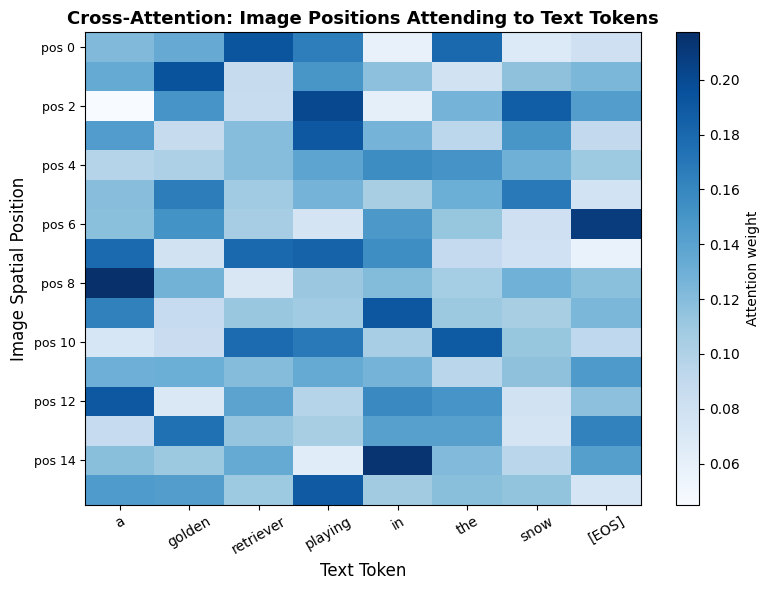

Each row shows how one image position distributes attention across text tokens.
Different positions attend to different words -- this is how text controls generation.


In [12]:
# Visualize the cross-attention pattern
attn_np = attn_weights[0].detach().numpy()  # (16, 8)

token_labels = ['a', 'golden', 'retriever', 'playing', 'in', 'the', 'snow', '[EOS]']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(attn_np, cmap='Blues', aspect='auto')
ax.set_xlabel('Text Token', fontsize=12)
ax.set_ylabel('Image Spatial Position', fontsize=12)
ax.set_title('Cross-Attention: Image Positions Attending to Text Tokens', fontsize=13, fontweight='bold')
ax.set_xticks(range(8))
ax.set_xticklabels(token_labels, fontsize=10, rotation=30)
ax.set_yticks(range(0, 16, 2))
ax.set_yticklabels([f'pos {i}' for i in range(0, 16, 2)], fontsize=9)
plt.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()

print("Each row shows how one image position distributes attention across text tokens.")
print("Different positions attend to different words -- this is how text controls generation.")

In [13]:
info_box(
    """<b>交叉注意力是关键机制</b>，它在 Stable Diffusion 中连接文本和图像。
    它被插入到 <b>UNet 的多个层</b>（在不同分辨率下），因此模型可以在
    粗略布局（低分辨率）和精细细节（高分辨率）两个层面使用文本信息。<br><br>
    在 SD v1.5 中，交叉注意力层出现在 64x64、32x32、16x16 和 8x8 分辨率级别。
    这种多尺度条件引导对于高质量的文本-图像对齐至关重要。""",
    title="Stable Diffusion 中的交叉注意力"
)

---
## 5. Stable Diffusion：完整流水线

现在让我们把所有部分组合起来。完整的 Stable Diffusion 流水线有四个主要组件，按顺序协同工作。

In [14]:
# Full Stable Diffusion pipeline diagram
render_plantuml("""
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title Stable Diffusion Pipeline: Text to Image

rectangle "Text Prompt\n'a cat on a beach'" as prompt #LightYellow
rectangle "CLIP Text Encoder\n(frozen, 63M params)" as clip #LightBlue
rectangle "Text Embeddings\n(1, 77, 768)" as textemb #PaleGreen

rectangle "Random Noise\n(1, 4, 64, 64)" as noise #LightGray

rectangle "UNet + Cross-Attention\n(860M params)\nx50 denoising steps" as unet #Salmon

rectangle "Clean Latent\n(1, 4, 64, 64)" as latent #PaleGreen

rectangle "VAE Decoder\n(49M params)" as vae #Plum

rectangle "Output Image\n(1, 3, 512, 512)" as image #LightGreen

prompt --> clip
clip --> textemb
textemb --> unet
noise --> unet
unet --> latent
latent --> vae
vae --> image

note right of unet
  For each step:
  1. UNet predicts noise
  2. Scheduler removes noise
  3. Repeat 50x
end note
@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12

title Stable Diffusion Pipeline: Text to Image

rectangle "Text Prompt
'a cat on a beach'" as prompt #LightYellow
rectangle "CLIP Text Encoder
(frozen, 63M params)" as clip #LightBlue
rectangle "Text Embeddings
(1, 77, 768)" as textemb #PaleGreen

rectangle "Random Noise
(1, 4, 64, 64)" as noise #LightGray

rectangle "UNet + Cross-Attention
(860M params)
x50 denoising steps" as unet #Salmon

rectangle "Clean Latent
(1, 4, 64, 64)" as latent #PaleGreen

rectangle "VAE Decoder
(49M params)" as vae #Plum

rectangle "Output Image
(1, 3, 512, 512)" as image #LightGreen

prompt --> clip
clip --> textemb
textemb --> unet
noise --> unet
unet --> latent
latent --> vae
vae --> image

note right of unet
  For each step:
  1. UNet predicts noise
  2. Scheduler removes noise
  3. Repeat 50x
end note
@enduml
```

In [15]:
# Walk through each component with real tensor shapes
torch.manual_seed(42)

print("=== Stable Diffusion Pipeline Step-by-Step ===")
print()

# Step 1: Text encoding
prompt = "a photograph of a golden retriever playing in snow"
text_embedding = torch.randn(1, 77, 768)  # CLIP output
print(f"Step 1: Text Encoding (CLIP ViT-L/14)")
print(f"  Prompt:  '{prompt}'")
print(f"  Output:  {list(text_embedding.shape)}  (77 tokens x 768 dimensions)")
print(f"  Note:    77 is the max token length; shorter prompts are padded")
print()

# Step 2: Initial noise in latent space
latent = torch.randn(1, 4, 64, 64)
print(f"Step 2: Initial Noise in Latent Space")
print(f"  Shape:   {list(latent.shape)}  ({latent.numel():,} values)")
print(f"  Compare: pixel space would be [1, 3, 512, 512] = {1*3*512*512:,} values")
print(f"  Savings: {1*3*512*512 / latent.numel():.0f}x fewer values")
print()

# Step 3: Iterative denoising
num_steps = 50
print(f"Step 3: Iterative Denoising ({num_steps} UNet forward passes)")
print(f"  Each step: UNet(noisy_latent, timestep, text_embedding) -> predicted_noise")
for step in [0, 10, 25, 49]:
    noise_level = 1.0 - step / num_steps
    print(f"    Step {step:2d}: noise_level={noise_level:.2f}")
print()

# Step 4: VAE decode
decoded = torch.randn(1, 3, 512, 512)  # simulated
print(f"Step 4: VAE Decode")
print(f"  Input:  {list(latent.shape)} (clean latent)")
print(f"  Output: {list(decoded.shape)} (final image)")

=== Stable Diffusion Pipeline Step-by-Step ===

Step 1: Text Encoding (CLIP ViT-L/14)
  Prompt:  'a photograph of a golden retriever playing in snow'
  Output:  [1, 77, 768]  (77 tokens x 768 dimensions)
  Note:    77 is the max token length; shorter prompts are padded

Step 2: Initial Noise in Latent Space
  Shape:   [1, 4, 64, 64]  (16,384 values)
  Compare: pixel space would be [1, 3, 512, 512] = 786,432 values
  Savings: 48x fewer values

Step 3: Iterative Denoising (50 UNet forward passes)
  Each step: UNet(noisy_latent, timestep, text_embedding) -> predicted_noise
    Step  0: noise_level=1.00
    Step 10: noise_level=0.80
    Step 25: noise_level=0.50
    Step 49: noise_level=0.02

Step 4: VAE Decode
  Input:  [1, 4, 64, 64] (clean latent)
  Output: [1, 3, 512, 512] (final image)


In [16]:
# Parameter and memory breakdown
components = {
    'CLIP Text Encoder': 63e6,
    'UNet (with cross-attn)': 860e6,
    'VAE (encoder + decoder)': 123e6,
}

print("=== Stable Diffusion v1.5 Parameter Count ===")
total = 0
for name, params in components.items():
    mem_fp16 = params * 2 / 1e9  # 2 bytes per param in FP16
    print(f"  {name:30s}  {params/1e6:>6.0f}M params  ({mem_fp16:.2f} GB in FP16)")
    total += params
print(f"  {'TOTAL':30s}  {total/1e6:>6.0f}M params  ({total * 2 / 1e9:.2f} GB in FP16)")

print()
print("=== Runtime Memory (batch=1, FP16) ===")
model_mem = total * 2 / 1e9
activation_mem = 1.0  # approximate
kv_cache_mem = 0.5    # approximate
total_runtime = model_mem + activation_mem + kv_cache_mem
print(f"  Model weights:  {model_mem:.1f} GB")
print(f"  Activations:    ~{activation_mem:.1f} GB")
print(f"  Attention KV:   ~{kv_cache_mem:.1f} GB")
print(f"  Total:          ~{total_runtime:.1f} GB")

info_box(
    "<b>Stable Diffusion v1.5</b> 拥有约 860M UNet 参数 + 123M VAE 参数 + 63M CLIP 参数 "
    "= <b>约 10 亿总参数</b>。在 FP16 下可以轻松放入 8GB 以上显存的消费级 GPU。",
    title="模型大小"
)

=== Stable Diffusion v1.5 Parameter Count ===
  CLIP Text Encoder                   63M params  (0.13 GB in FP16)
  UNet (with cross-attn)             860M params  (1.72 GB in FP16)
  VAE (encoder + decoder)            123M params  (0.25 GB in FP16)
  TOTAL                             1046M params  (2.09 GB in FP16)

=== Runtime Memory (batch=1, FP16) ===
  Model weights:  2.1 GB
  Activations:    ~1.0 GB
  Attention KV:   ~0.5 GB
  Total:          ~3.6 GB


In [17]:
# Cross-links to related notebooks
info_box(
    """<b>本系列中的相关主题：</b><br><br>
    如何在大规模生产中高效地部署扩散模型，请参阅：
    <ul>
    <li><a href='../../zh/inference/00-kv-cache.ipynb'>KV-Cache</a>——注意力层的缓存策略</li>
    <li><a href='../../zh/inference/05-quantization-pruning.ipynb'>量化</a>——使用 INT8/INT4 缩小模型体积</li>
    </ul>
    关于取代 UNet 的新型 Transformer 方案，请参阅：
    <ul>
    <li><a href='04-dit-architecture.ipynb'>DiT 架构</a>——扩散 Transformer</li>
    </ul>""",
    title="延伸探索"
)

---
## 6. 工程考量

从研究到生产部署 Stable Diffusion，涉及多个实际考量，这些因素会显著影响生成质量和性能。

In [18]:
# VAE precision matters: demonstrate the scaling factor
print("=== VAE Precision and Scaling ===")
print()

# The magic scaling factor in SD v1
vae_scaling_factor = 0.18215
print(f"VAE latent scaling factor: {vae_scaling_factor}")
print(f"")
print("Why this number? The raw VAE latent has a standard deviation of ~{:.1f}.".format(1/vae_scaling_factor))
print(f"Multiplying by {vae_scaling_factor} normalizes latents to approximately unit variance,")
print(f"which matches the assumption of the noise schedule (N(0, 1) noise).")
print()

# Show FP16 vs FP32 precision for VAE values
raw_latent = torch.randn(1, 4, 8, 8) / vae_scaling_factor  # raw VAE output (large values)
scaled_latent = raw_latent * vae_scaling_factor               # normalized for diffusion

print(f"Raw VAE output range:    [{raw_latent.min():.2f}, {raw_latent.max():.2f}]")
print(f"Scaled latent range:     [{scaled_latent.min():.2f}, {scaled_latent.max():.2f}]")
print()

# FP16 precision demonstration
raw_fp16 = raw_latent.half()
raw_fp16_error = (raw_fp16.float() - raw_latent).abs().max().item()
scaled_fp16 = scaled_latent.half()
scaled_fp16_error = (scaled_fp16.float() - scaled_latent).abs().max().item()

print(f"FP16 quantization error:")
print(f"  Raw VAE output:   max error = {raw_fp16_error:.6f}")
print(f"  Scaled latent:    max error = {scaled_fp16_error:.6f}")
print(f"")
print("Larger values lose more precision in FP16. This is why the VAE decoder")
print("should use FP32 -- it operates on large-range pixel values.")

=== VAE Precision and Scaling ===

VAE latent scaling factor: 0.18215

Why this number? The raw VAE latent has a standard deviation of ~5.5.
Multiplying by 0.18215 normalizes latents to approximately unit variance,
which matches the assumption of the noise schedule (N(0, 1) noise).

Raw VAE output range:    [-13.47, 15.16]
Scaled latent range:     [-2.45, 2.76]

FP16 quantization error:
  Raw VAE output:   max error = 0.003545
  Scaled latent:    max error = 0.000934

Larger values lose more precision in FP16. This is why the VAE decoder
should use FP32 -- it operates on large-range pixel values.


In [19]:
info_box(
    """<b>生产环境建议：</b>VAE 解码器务必使用 <b>FP32 或 BF16</b>，绝不要用 FP16。
    FP16 的 VAE 解码是部署系统中"奇怪颜色伪影"的头号原因。<br><br>
    UNet 可以安全地使用 FP16 运行，因为其内部值范围良好。
    但 VAE 解码器输出的像素值在 [0, 255] 范围内，FP16 有限的精度
    会导致可见的色带和颜色偏移。""",
    title="生产环境建议"
)

In [20]:
# SDXL improvements over SD v1.5
print("=== SDXL vs SD v1.5: Key Improvements ===")
print()

improvements = [
    ("UNet size",          "860M params",       "2.6B params",       "3x larger, better quality"),
    ("Text encoders",      "CLIP ViT-L (1x)",   "CLIP ViT-L + OpenCLIP ViT-bigG (2x)", "Better text understanding"),
    ("Latent resolution",  "64x64x4",           "128x128x4",         "4x more latent detail"),
    ("Output resolution",  "512x512",           "1024x1024",         "4x more pixels"),
    ("Conditioning",       "Text only",         "Text + micro-conditioning", "Original size, crop coords"),
    ("Model memory (FP16)","~2.7 GB",           "~8.2 GB",           "Needs bigger GPU"),
]

print(f"{'Feature':<22} {'SD v1.5':<22} {'SDXL':<30} {'Why'}")
print("-" * 100)
for feat, sd15, sdxl, why in improvements:
    print(f"{feat:<22} {sd15:<22} {sdxl:<30} {why}")

print()
print("Micro-conditioning in SDXL: the model is trained with (original_height, original_width,")
print("crop_top, crop_left, target_height, target_width) as additional conditioning signals.")
print("This avoids the common problem of generating cropped or low-res-looking images.")

=== SDXL vs SD v1.5: Key Improvements ===

Feature                SD v1.5                SDXL                           Why
----------------------------------------------------------------------------------------------------
UNet size              860M params            2.6B params                    3x larger, better quality
Text encoders          CLIP ViT-L (1x)        CLIP ViT-L + OpenCLIP ViT-bigG (2x) Better text understanding
Latent resolution      64x64x4                128x128x4                      4x more latent detail
Output resolution      512x512                1024x1024                      4x more pixels
Conditioning           Text only              Text + micro-conditioning      Original size, crop coords
Model memory (FP16)    ~2.7 GB                ~8.2 GB                        Needs bigger GPU

Micro-conditioning in SDXL: the model is trained with (original_height, original_width,
crop_top, crop_left, target_height, target_width) as additional conditioning signals.


---
## 总结

| 概念 | 核心思想 |
|------|----------|
| **潜在空间** | 将图像压缩为约 48 倍更小的张量，在其中完成所有扩散工作 |
| **VAE** | 编码器压缩为潜在表示，解码器重建为像素（单独训练后冻结） |
| **UNet** | ResBlocks + 注意力 + 跳跃连接，用于迭代去噪 |
| **交叉注意力** | Q 来自图像，K/V 来自文本——文本控制生成的机制 |
| **完整流水线** | 文本 -> CLIP -> 噪声 -> UNet x N -> VAE 解码 -> 图像 |
| **工程实践** | VAE 解码器使用 FP32；缩放因子归一化潜在方差；SDXL 添加微条件 |

### 核心要点

- 潜在扩散不是一种近似——VAE 保留了足够的信息来生成高质量图像
- 交叉注意力是使文本到图像成为可能的核心机制
- 工程上的收益（内存、批次大小、速度）与算法上的收益同样重要
- 在生产环境中，VAE 精度和潜在缩放是常见的 bug 来源

### 参考文献

- [High-Resolution Image Synthesis with Latent Diffusion Models (Rombach et al., 2022)](https://arxiv.org/abs/2112.10752)
- [Stable Diffusion Blog Post](https://stability.ai/blog/stable-diffusion-public-release)
- [Understanding Diffusion Models: A Unified Perspective (Luo, 2022)](https://arxiv.org/abs/2208.11970)

### 下一篇：[04 - DiT 架构](04-dit-architecture.ipynb) —— 用 Transformer 替代 UNet 会怎样？